In [6]:
# FGBUSTER IMPORTS
import healpy as hp
import pysm3

from fgbuster import ( get_observation, get_instrument)

# FURAX IMPORTS
import jax
import jaxopt
import jax.numpy as jnp
from jax import ShapeDtypeStruct

from furax._base.blocks import BlockDiagonalOperator, BlockRowOperator
from furax._base.core import HomothetyOperator, IdentityOperator
from furax.landscapes import StokesPyTree, ValidStokesType, HealpixLandscape
from furax.tree import as_structure
from furax.operators.sed import CMBOperator, DustOperator, SynchrotronOperator
import operator
from math import prod
import numpy as np

import os
import pickle
from functools import partial

In [2]:
instrument = get_instrument('LiteBIRD')

def generate_maps(nside,noise=False):
    npixel = nside ** 2 * 12
    # Define cache file path
    cache_dir = 'freq_maps_cache'
    os.makedirs(cache_dir, exist_ok=True)
    noise_str = 'noise' if noise else 'no_noise'
    cache_file = os.path.join(cache_dir, f'freq_maps_nside_{nside}_{noise_str}.pkl')

    # Check if file exists, load if it does, otherwise create and save it
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            freq_maps = pickle.load(f)
        print(f"Loaded freq_maps for nside {nside} from cache.")
    else:
        # Generate freq_maps if not already cached
        freq_maps = get_observation(instrument, 'c1d0s0', nside=nside,noise=noise)
        
        # Save freq_maps to the cache
        with open(cache_file, 'wb') as f:
            pickle.dump(freq_maps, f)
        print(f"Generated and saved freq_maps for nside {nside}.")

    # Check the shape of freq_maps
    print("freq_maps shape:", freq_maps.shape)


nsides = [32]
for nside in nsides:
    generate_maps(nside , noise=False)
    generate_maps(nside , noise=True)

Generated and saved freq_maps for nside 32.
freq_maps shape: (15, 3, 12288)
Generated and saved freq_maps for nside 32.
freq_maps shape: (15, 3, 12288)


In [3]:
nside = 32
npixel = nside ** 2 * 12
dust_nu0 = 150.0
synchrotron_nu0 = 20.0
noise = False
stokes_type: ValidStokesType = 'IQU'
instrument = get_instrument('LiteBIRD')

noise_str = 'noise' if noise else 'no_noise'
# Define cache file path
cache_dir = 'freq_maps_cache'
cache_file = os.path.join(cache_dir, f'freq_maps_nside_{nside}_{noise_str}.pkl')

# Check if file exists and load if it does; otherwise raise an error with guidance
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        freq_maps = pickle.load(f)
    print(f"Loaded freq_maps for nside {nside} from cache.")
else:
    raise FileNotFoundError(
        f"Cache file for freq_maps with nside {nside} not found.\n"
        f"Please generate it first by calling `generate_maps({nside})`."
    )

# Check the shape of freq_maps
print("freq_maps shape:", freq_maps.shape)

Loaded freq_maps for nside 32 from cache.
freq_maps shape: (15, 3, 12288)


In [4]:
d = StokesPyTree.from_stokes(I=freq_maps[:,0,:], Q=freq_maps[:,1,:], U=freq_maps[:,2,:])
d.structure

StokesIQUPyTree(i=ShapeDtypeStruct(shape=(15, 12288), dtype=float64), q=ShapeDtypeStruct(shape=(15, 12288), dtype=float64), u=ShapeDtypeStruct(shape=(15, 12288), dtype=float64))

In [8]:
from furax.comp_sep import spectral_log_likelihood, spectral_cmb_variance, negative_log_likelihood

dust_nu0 = 150.
synchrotron_nu0 = 20.
nu = instrument['frequency'].values

negative_log_likelihood = partial(negative_log_likelihood , dust_nu0=dust_nu0, synchrotron_nu0=synchrotron_nu0)
spectral_log_likelihood = partial(spectral_log_likelihood , dust_nu0=dust_nu0, synchrotron_nu0=synchrotron_nu0)

In [ ]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

N = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)

@jax.jit
def log_prob(params, d):
    return spectral_log_likelihood(params, nu=nu, d=d, N=N)
# Define the model with the likelihood function
def model(d):
    # Define priors with uniform distributions
    temp_dust = numpyro.sample("temp_dust", dist.Uniform(15, 30))
    beta_dust = numpyro.sample("beta_dust", dist.Uniform(0.5, 3.0))
    beta_pl = numpyro.sample("beta_pl", dist.Uniform(-6, -1))
    
    # Pack parameters into a dictionary for passing to likelihood function
    params = {"temp_dust": temp_dust, "beta_dust": beta_dust, "beta_pl": beta_pl}
    
    # Calculate the negative log-likelihood using the `likelihood` function
    L = log_prob(params, d)
    
    # Specify the likelihood as a factor in NumPyro
    numpyro.factor("log_prob", L ) 

# Set up the NUTS sampler
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=1)

# Run the MCMC inference
# `d` should be the observed data that is passed to the model
mcmc.run(jax.random.PRNGKey(0), d=d)

mcmc.print_summary()


sample:  73%|███████▎  | 1100/1500 [05:23<05:22,  1.24it/s, 127 steps of size 2.16e-04. acc. prob=0.95]

In [90]:
import arviz as az

inf_data = az.from_numpyro(mcmc)
az.summary(inf_data)


arviz - WARNING - Shape validation failed: input_shape: (1, 400), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_dust,1.531,0.016,1.498,1.541,0.010,0.008,7.0,11.0,NaN
beta_pl,-2.819,0.333,-3.037,-2.142,0.212,0.173,7.0,11.0,NaN
temp_dust,20.300,0.561,19.953,21.481,0.355,0.288,7.0,11.0,NaN


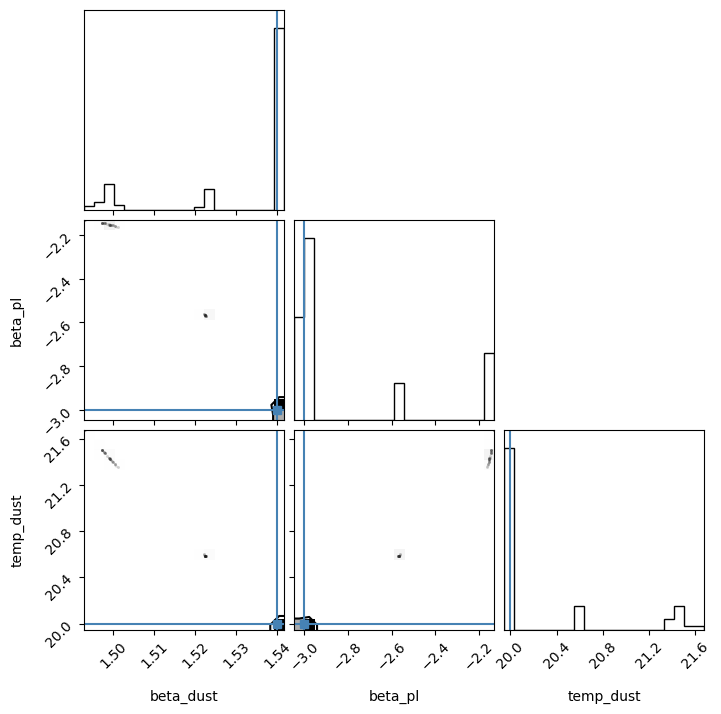

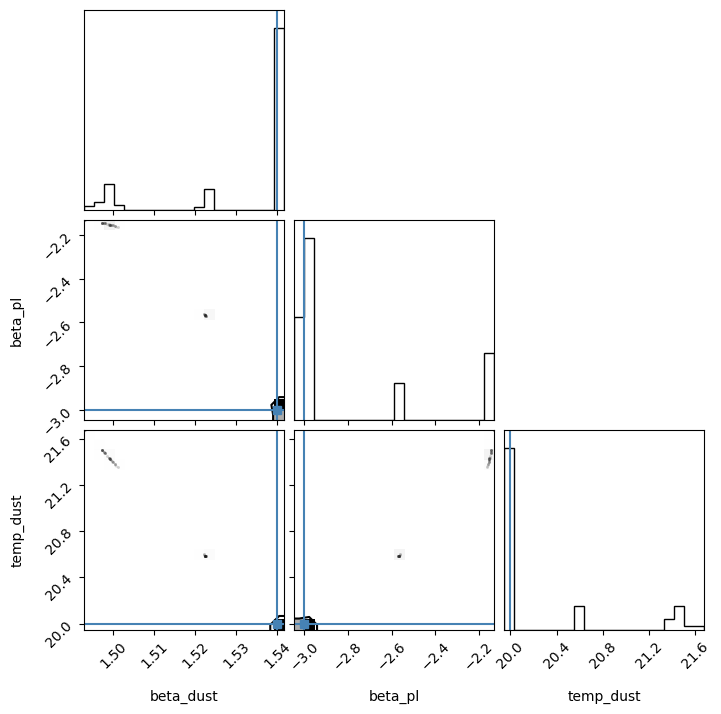

In [91]:
import corner

best_param = {'beta_dust': 1.54, 'beta_pl': -3.0, 'temp_dust': 20.0}
corner.corner(inf_data, truths=true_params)


In [18]:
nside = 32
npixel = nside ** 2 * 12
dust_nu0 = 150.0
synchrotron_nu0 = 20.0
noise = True
stokes_type: ValidStokesType = 'IQU'
instrument = get_instrument('LiteBIRD')

noise_str = 'noise' if noise else 'no_noise'
# Define cache file path
cache_dir = 'freq_maps_cache'
cache_file = os.path.join(cache_dir, f'freq_maps_nside_{nside}_{noise_str}.pkl')

# Check if file exists and load if it does; otherwise raise an error with guidance
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        noisy_freq_maps = pickle.load(f)
    print(f"Loaded freq_maps for nside {nside} from cache.")
else:
    raise FileNotFoundError(
        f"Cache file for freq_maps with nside {nside} not found.\n"
        f"Please generate it first by calling `generate_maps({nside})`."
    )

# Check the shape of freq_maps
print("freq_maps shape:", noisy_freq_maps.shape)

Loaded freq_maps for nside 32 from cache.
freq_maps shape: (15, 3, 12288)


In [19]:
noisy_sky = StokesPyTree.from_stokes(I=noisy_freq_maps[:,0,:], Q=noisy_freq_maps[:,1,:], U=noisy_freq_maps[:,2,:])
structure = HealpixLandscape(nside, stokes_type).structure
d.structure

StokesIQUPyTree(i=ShapeDtypeStruct(shape=(15, 12288), dtype=float64), q=ShapeDtypeStruct(shape=(15, 12288), dtype=float64), u=ShapeDtypeStruct(shape=(15, 12288), dtype=float64))

In [ ]:
# Set up the NUTS sampler
nuts_kernel = NUTS(model)
sampler_with_noise = MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=1)

# Run the MCMC inference
sampler_with_noise.run(jax.random.PRNGKey(0), d=noisy_sky)

sampler_with_noise.print_summary()

sample: 100%|██████████| 1500/1500 [22:32<00:00,  1.11it/s, 3 steps of size 1.51e-03. acc. prob=0.94]  


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  beta_dust      1.54      0.00      1.54      1.54      1.54    189.09      1.00
    beta_pl     -3.00      0.00     -3.00     -3.00     -3.00    214.55      1.00
  temp_dust     20.00      0.00     20.00     20.00     20.00    192.83      1.00

Number of divergences: 0


In [22]:
import arviz as az

inf_data = az.from_numpyro(sampler_with_noise)
az.summary(inf_data)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_dust,1.54,0.000,1.540,1.540,0.0,0.0,202.0,293.0,NaN
beta_pl,-3.00,0.001,-3.002,-2.998,0.0,0.0,219.0,195.0,NaN
temp_dust,20.00,0.002,19.995,20.004,0.0,0.0,205.0,285.0,NaN


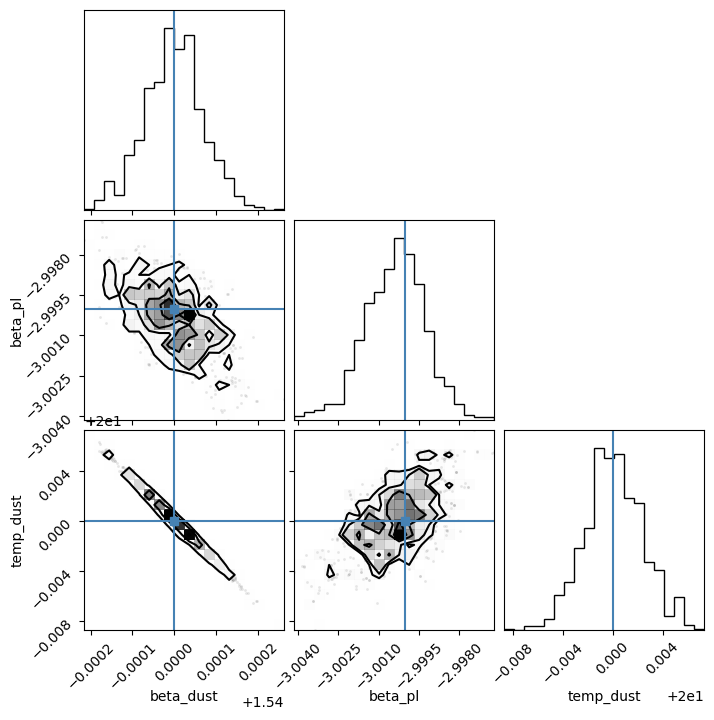

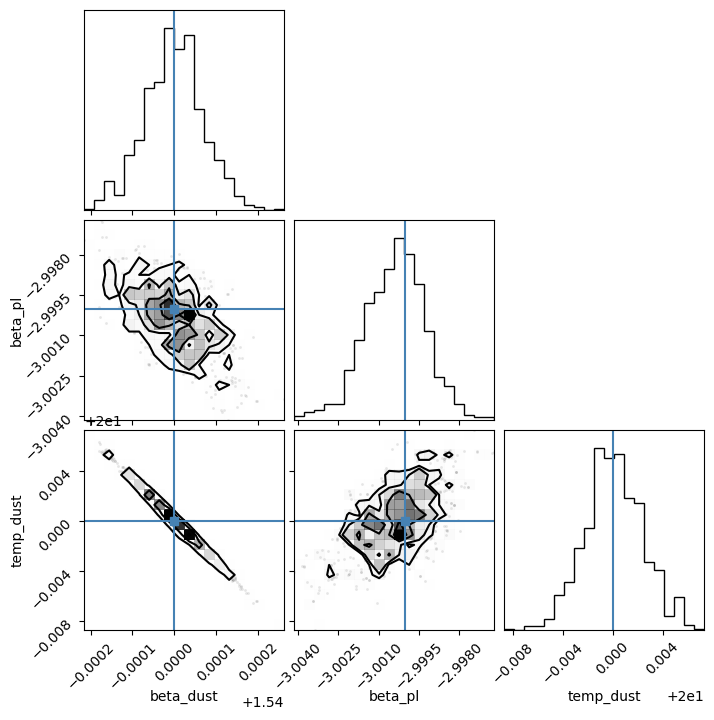

In [28]:
import corner

best_param = {'beta_dust': 1.54, 'beta_pl': -3.0, 'temp_dust': 20.0}
corner.corner(inf_data, var_names=["beta_dust", "beta_pl" , "temp_dust"], truths=best_param)

In [24]:
from fgbuster import (CMB, Dust, Synchrotron, 
                      basic_comp_sep, MixingMatrix,
                      get_observation, get_instrument)

components = [CMB(), Dust(dust_nu0), Synchrotron(synchrotron_nu0)]

components[1]._set_default_of_free_symbols(beta_d=2.54,temp=25.)
components[2]._set_default_of_free_symbols(beta_pl=-6.0)

result = basic_comp_sep(components, instrument, noisy_freq_maps)
print(result.params)
print(result.x)

['Dust.beta_d', 'Dust.temp', 'Synchrotron.beta_pl']
[ 1.53999284 20.00028024 -3.00004451]
